In [1]:
#############################################
#BASIC PACKAGES
import sys
from copy import deepcopy as dcopy
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#############################################
#PATH TO SCRIPTS FOLDER|
path = '/data/AMARINS/LSSxHI-CODES/scripts/'
sys.path.insert(1, path)
import cross_functions_theory      as cxft
import handling_data               as hdata

#############################################
## MATPLOTLIB FEATURES
import matplotlib as mpl
from matplotlib import cm
font = {'weight' : 'bold','size'   : 22}
mpl.rc('font', **font)
mpl.rc('font',   size=209)  #set defaults so that the plots are readable
mpl.rc('axes',   titlesize=20)
mpl.rc('axes',   labelsize=20)
mpl.rc('xtick',  labelsize=20)
mpl.rc('ytick',  labelsize=20)
mpl.rc('legend', fontsize =20)
mpl.rc('figure', titlesize=20)
mpl.rc('text',   usetex=True)
## FURTHER MATPLOTLIB FEATURES
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
#np.set_printoptions(precision=3)

In [4]:
['LSSTY10_bin{}_40_0001'.format(i) for i in range(5)]

['LSSTY10_bin0_40_0001',
 'LSSTY10_bin1_40_0001',
 'LSSTY10_bin2_40_0001',
 'LSSTY10_bin3_40_0001',
 'LSSTY10_bin4_40_0001']

In [11]:
##########################################
## THEORETICAL
## LSST Y10
prefix = ['LSST_bin{}_40_0001'.format(i) for i in range(5)]
suffix = "LOWZ"
f1name = 'HI'
f2name = 'DENSITY'
bshear_names = np.array([     iprefix.split('_')[1] for iprefix in prefix    ])
bshear_used  = np.array([ int(ibin.split('bin')[1]) for ibin    in bshear_names ])
##########################################
## PATH to THEORECTICAL APS 
filepath_f1_ecl = np.array(['/data/AMARINS/LSSxHI-DATA/theoretical/GCxHI/{}_{f1}_cl_{}.txt'.format(iprefix, suffix, f1=f1name) for iprefix in prefix ])
filepath_f2_ecl = np.array(['/data/AMARINS/LSSxHI-DATA/theoretical/GCxHI/{}_{f2}_cl_{}.txt'.format(iprefix, suffix, f2=f2name) for iprefix in prefix ])
filepath_cx_ecl = np.array(['/data/AMARINS/LSSxHI-DATA/theoretical/GCxHI/{}_{f1}x{f2}_cl_{}.txt'.format(iprefix, suffix,f1=f1name, f2=f2name) for iprefix in prefix ])
##
savefigs = True

In [12]:
##########################################
## LOADING DATA
Clf1_dict,Clf2_dict,Clcx_dict = {}, {}, {}
for i, (ibin, if1_path, if2_path, icx_path) in enumerate(zip(bshear_names, filepath_f1_ecl, filepath_f2_ecl, filepath_cx_ecl)):
    ##
    clf1 = np.loadtxt(if1_path).T
    clf2 = np.loadtxt(if2_path).T
    clcx = np.loadtxt(icx_path ).T
    ##
    Clf1_dict[ibin] = cxft.cls_from_matrix2dict(clf1)
    Clf2_dict[ibin] = cxft.cls_from_matrix2dict(clf2)
    Clcx_dict[ibin] = cxft.cls_from_matrix2dict(clcx)
    ##
    nch = int(clf1.shape[0])-1
    del clf1, clf2, clcx

In [13]:
################################
# REDSHIFT TO BE REPRESENTED
nch       = 30
N         = 4
zeff      = cxft.get_zeff(numin =980, numax =1260, nbands= nch, n_curves=N)['zeff']
ibins     = cxft.get_zeff(numin =980, numax =1260, nbands= nch, n_curves=N)['bins']
cticks    = dcopy(ibins)+1
bin_names = np.asarray( list(Clcx_dict[bshear_names[0]].keys())[1:])
################################

In [14]:
import pymaster as nmt
b = nmt.NmtBin.from_nside_linear(256, nlb=4)
leff  = b.get_effective_ells()

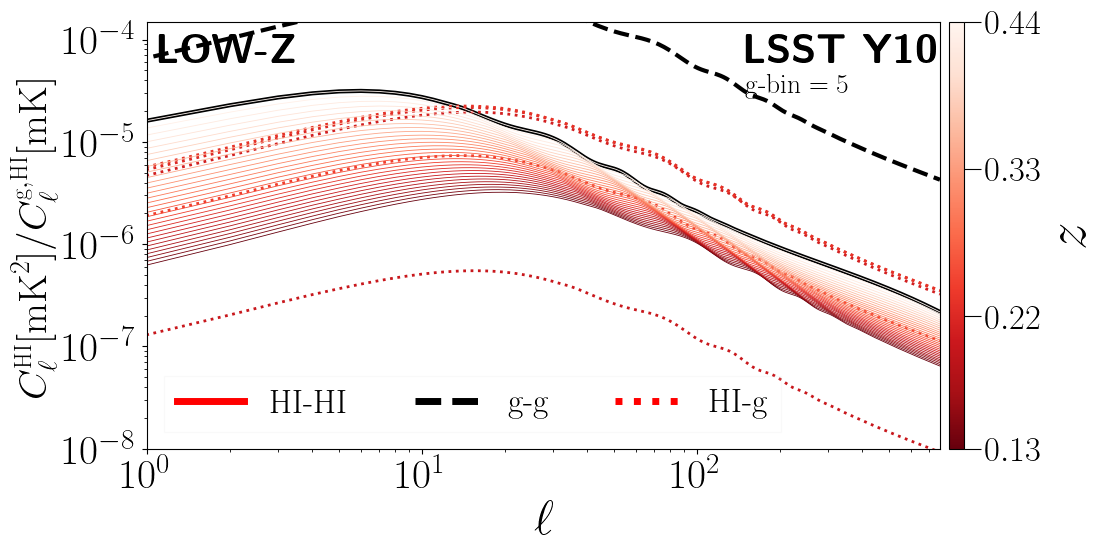

'/data/AMARINS/LSSxHI-CODES/images/LSST_bin4_40_0001_cl_hi_theory_density_LOWZ2.png'

In [21]:
fig, ax  = plt.subplots(nrows=1, ncols=1)
plt.subplots_adjust(top=1.,right=1.6)
############################################################
c    = ibins
norm = mpl.colors.Normalize(vmin=1, vmax=int(nch))
cmap_f1 = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds.reversed())
cmap_f1.set_array([])
cmap_cx = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds_r)#.reversed())
cmap_cx.set_array([])
############################################################
### LSST Y10 bin1
jj=4
ishear = bshear_names[jj]
#
ax.plot(Clcx_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')
ax.plot(Clf1_dict[ishear]['l'], Clf1_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')     
for i,iname in enumerate(np.flip(bin_names)):
    if iname!='l':
        thres = 1e-25
        cx = dcopy(Clcx_dict[ishear][iname])
        ind = np.where( (cx<thres)*(cx>-thres) )
        cx[ind]=0        
        ax.plot(Clcx_dict[ishear]['l'], cx, linestyle='dotted', lw=2, color=cmap_cx.to_rgba(i + 1))
    if iname!='l':ax.plot(Clf1_dict[ishear]['l'], Clf1_dict[ishear][iname], linestyle='solid', lw=0.6,color=cmap_f1.to_rgba(i + 1))   
ax.plot(Clf1_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(nch)],linestyle='solid', linewidth=1, color='black')   

ax.plot(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin{}'.format(1)],linestyle='dashed', linewidth=3, color='black')   

#ax.plot(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin1'],linestyle='dashed', color='black', lw=3)
#
ax.set_ylabel(r'$C_{\ell}\ [\textrm{mK}^{\Large\textrm{(m)}}]$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_ylabel(r'$C^{\LARGE{\textrm{HI}}}_{\ell}[\textrm{mK}^2]$' + r'$/$'+ r'$C^{\LARGE{\textrm{g}},\LARGE{\textrm{HI}}}_{\ell}[\textrm{mK}]$', fontsize=29); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_xlim([1, Clf2_dict[ishear]['l'].max()])
ax.set_ylim([1e-8, 1.5e-4])
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_yscale('log'); ax.set_xscale('log')
############################################################
cbar=fig.colorbar(cmap_cx, ax=ax, #location='top',
                  orientation='vertical',# extend="both",
                  pad=0.01, aspect=30, ticks=cticks,
                  format=mticker.FixedFormatter(np.array([ r'${:.2f}$'.format(izeff) for izeff in np.flip(zeff) ])) )
cbar.ax.tick_params(axis='both', which='major', labelsize=25, length=12)
cbar.set_label( label=r'$z$', fontsize=40)
###########################################################
custom_lines = [Line2D([], [], color='red',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='black',
                             linewidth=5, linestyle='dashed'),
                Line2D([], [], color='red',
                             linewidth=5, linestyle='dotted')
               ]
ax.legend(custom_lines, [r'$\textrm{HI-HI}$',#\ [\textrm{mK}^2]$',#\ (\textrm{m}=2)$', 
                         r'$\textrm{g-g}$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                         r'$\textrm{HI-g}$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                        ], ncols=3,
         fontsize=24, loc='lower left',framealpha=0.1, fancybox=False)

ax.text(x=1.1    , y=0.6e-4, s=r'$\textbf{LOW-Z}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-150, y=0.6e-4, s=r'$\textbf{LSST Y10}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-150, y=3.0e-5, s=r'$\textrm{g-bin} = '+'{}$'.format(int(ishear.split('bin')[1])+1), 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 20})
###########################################################
if suffix==None: pathname = "/data/AMARINS/LSSxHI-CODES/images/{}_{}_density2.png".format( prefix[jj], 'cl_hi_theory')
else:            pathname = "/data/AMARINS/LSSxHI-CODES/images/{}_{}_density_{}2.png".format(prefix[jj], 'cl_hi_theory',suffix)
if savefigs: plt.savefig(pathname, dpi=100, bbox_inches='tight');
plt.show()
pathname


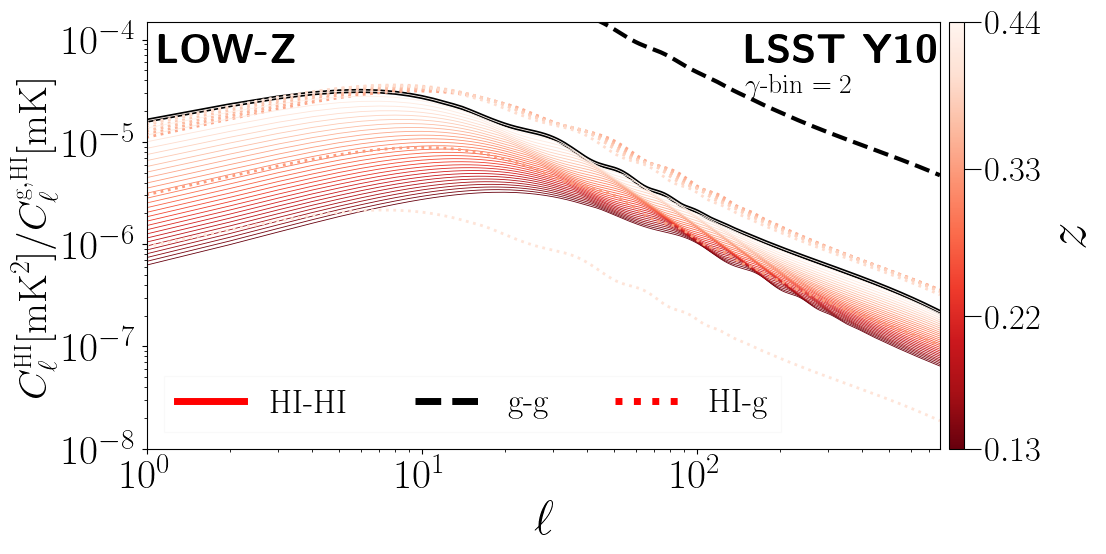

In [18]:
fig, ax  = plt.subplots(nrows=1, ncols=1)
plt.subplots_adjust(top=1.,right=1.6)
############################################################
c    = ibins
norm = mpl.colors.Normalize(vmin=1, vmax=int(nch))
cmap_f1 = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds.reversed())
cmap_f1.set_array([])
cmap_cx = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds_r)#.reversed())
cmap_cx.set_array([])
############################################################
### LSST Y10 bin1
jj=1
ishear = bshear_names[jj]
#
ax.plot(Clcx_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')
ax.plot(Clf1_dict[ishear]['l'], Clf1_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')     
for i,iname in enumerate(np.flip(bin_names)):
    if iname!='l':
        thres = 1e-25
        cx = dcopy(Clcx_dict[ishear][iname])
        ind = np.where( (cx<thres)*(cx>-thres) )
        cx[ind]=0        
        ax.plot(Clcx_dict[ishear]['l'], cx, linestyle='dotted', lw=2, color=cmap_cx.to_rgba(i + 1))
    if iname!='l':ax.plot(Clf1_dict[ishear]['l'], Clf1_dict[ishear][iname], linestyle='solid', lw=0.6,color=cmap_f1.to_rgba(i + 1))   
ax.plot(Clf1_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(nch)],linestyle='solid', linewidth=1, color='black')   

ax.plot(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin{}'.format(1)],linestyle='dashed', linewidth=3, color='black')   

#ax.plot(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin1'],linestyle='dashed', color='black', lw=3)
#
ax.set_ylabel(r'$C_{\ell}\ [\textrm{mK}^{\Large\textrm{(m)}}]$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_ylabel(r'$C^{\LARGE{\textrm{HI}}}_{\ell}[\textrm{mK}^2]$' + r'$/$'+ r'$C^{\LARGE{\textrm{g}},\LARGE{\textrm{HI}}}_{\ell}[\textrm{mK}]$', fontsize=29); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_xlim([1, Clf2_dict[ishear]['l'].max()])
ax.set_ylim([1e-8, 1.5e-4])
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_yscale('log'); ax.set_xscale('log')
############################################################
cbar=fig.colorbar(cmap_cx, ax=ax, #location='top',
                  orientation='vertical',# extend="both",
                  pad=0.01, aspect=30, ticks=cticks,
                  format=mticker.FixedFormatter(np.array([ r'${:.2f}$'.format(izeff) for izeff in np.flip(zeff) ])) )
cbar.ax.tick_params(axis='both', which='major', labelsize=25, length=12)
cbar.set_label( label=r'$z$', fontsize=40)
###########################################################
custom_lines = [Line2D([], [], color='red',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='black',
                             linewidth=5, linestyle='dashed'),
                Line2D([], [], color='red',
                             linewidth=5, linestyle='dotted')
               ]
ax.legend(custom_lines, [r'$\textrm{HI-HI}$',#\ [\textrm{mK}^2]$',#\ (\textrm{m}=2)$', 
                         r'$\textrm{g-g}$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                         r'$\textrm{HI-g}$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                        ], ncols=3,
         fontsize=24, loc='lower left',framealpha=0.1, fancybox=False)

ax.text(x=1.1    , y=0.6e-4, s=r'$\textbf{LOW-Z}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-150, y=0.6e-4, s=r'$\textbf{LSST Y10}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-150, y=3.0e-5, s=r'$\gamma\textrm{-bin} = '+'{}$'.format(int(ishear.split('bin')[1])+1), 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 20})
###########################################################
if suffix==None: pathname = "/data/AMARINS/LSSxHI-CODES/images/{}_{}_density2.png".format( prefix[jj], 'cl_hi_theory')
else:            pathname = "/data/AMARINS/LSSxHI-CODES/images/{}_{}_density_{}2.png".format(prefix[jj], 'cl_hi_theory',suffix)
if savefigs: plt.savefig(pathname, dpi=100, bbox_inches='tight');
pathname
plt.show()

'/data/AMARINS/LSSxHI-CODES/images/LSSTY10_bin2_cl_hi_theory_density_nch30_980_1260.png'

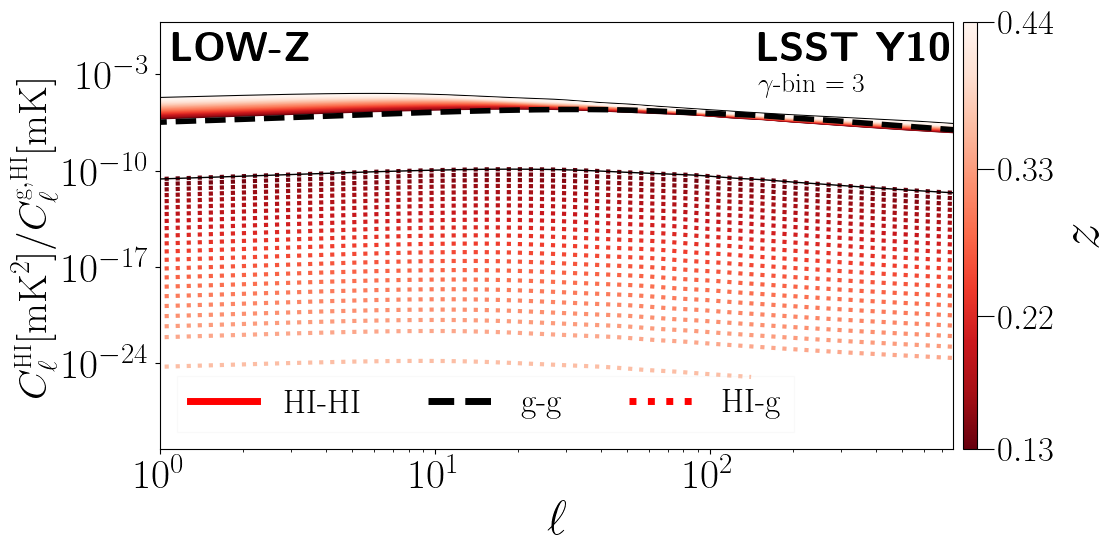

In [33]:
fig, ax  = plt.subplots(nrows=1, ncols=1)
plt.subplots_adjust(top=1.,right=1.6)
############################################################
c    = ibins
norm = mpl.colors.Normalize(vmin=1, vmax=int(nch))
cmap_f1 = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds.reversed())
cmap_f1.set_array([])
cmap_cx = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds_r)#.reversed())
cmap_cx.set_array([])
############################################################
### LSST Y10 bin1
jj=1
ishear = bshear_names[jj]
#
ax.plot(Clcx_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')
ax.plot(Clf1_dict[ishear]['l'], Clf1_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')     
for i,iname in enumerate(np.flip(bin_names)):
    if iname!='l':
        thres = 1e-25
        l  = Clcx_dict[ishear]['l']
        cl = Clcx_dict[ishear][iname]
        idx = np.where(cl>thres)
        ax.plot(l[idx], cl[idx], color=cmap_cx.to_rgba(i + 1), lw=3, ls='dotted')
    if iname!='l':ax.plot(Clf1_dict[ishear]['l'], Clf1_dict[ishear][iname], linestyle='solid', color=cmap_f1.to_rgba(i + 1))   
ax.plot(Clf1_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(nch)],linestyle='solid', linewidth=1, color='black')   
ax.plot(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin{}'.format(1)],linestyle='dashed', linewidth=4, color='black')   
#
ax.set_ylabel(r'$C_{\ell}\ [\textrm{mK}^{\Large\textrm{(m)}}]$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_ylabel(r'$C^{\LARGE{\textrm{HI}}}_{\ell}[\textrm{mK}^2]$' + r'$/$'+ r'$C^{\LARGE{\textrm{g}},\LARGE{\textrm{HI}}}_{\ell}[\textrm{mK}]$', fontsize=29); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_xlim([1, Clf2_dict[ishear]['l'].max()])
ax.set_ylim([0.6e-30, 7e0])
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_yscale('log'); ax.set_xscale('log')
############################################################
cbar=fig.colorbar(cmap_cx, ax=ax, #location='top',
                  orientation='vertical',# extend="both",
                  pad=0.01, aspect=30, ticks=cticks,
                  format=mticker.FixedFormatter(np.array([ r'${:.2f}$'.format(izeff) for izeff in np.flip(zeff) ])) )
cbar.ax.tick_params(axis='both', which='major', labelsize=25, length=12)
cbar.set_label( label=r'$z$', fontsize=40)
###########################################################
custom_lines = [Line2D([], [], color='red',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='black',
                             linewidth=5, linestyle='dashed'),
                Line2D([], [], color='red',
                             linewidth=5, linestyle='dotted')
               ]
ax.legend(custom_lines, [r'$\textrm{HI-HI}$',#\ [\textrm{mK}^2]$',#\ (\textrm{m}=2)$', 
                         r'$\textrm{g-g}$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                         r'$\textrm{HI-g}$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                        ], ncols=3,
         fontsize=24, loc='lower left',framealpha=0.1, fancybox=False)

ax.text(x=1.1    , y=1e-2, s=r'$\textbf{LOW-Z}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-150, y=1e-2, s=r'$\textbf{LSST Y10}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-150, y=0.5e-4, s=r'$\gamma\textrm{-bin} = '+'{}$'.format(int(ishear.split('bin')[1])+1), 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 20})
###########################################################
if suffix==None: pathname = "/data/AMARINS/LSSxHI-CODES/images/{}_{}_density.png".format( prefix[jj], 'cl_hi_theory')
else:            pathname = "/data/AMARINS/LSSxHI-CODES/images/{}_{}_density_{}.png".format(prefix[jj], 'cl_hi_theory',suffix)
#if savefigs: plt.savefig(pathname, dpi=100, bbox_inches='tight');
pathname

# HIGH-z

In [2]:
##########################################
## THEORETICAL
## LSST Y10
prefix = ['LSSTY10_bin0','LSSTY10_bin1', 'LSSTY10_bin2', 'LSSTY10_bin3', 'LSSTY10_bin4']
suffix = 'nch70_350_1050'
f1name = 'HI'
f2name = 'DENSITY'
bshear_names = np.array([     iprefix.split('_')[1] for iprefix in prefix    ])
bshear_used  = np.array([ int(ibin.split('bin')[1]) for ibin    in bshear_names ])
##########################################
## PATH to THEORECTICAL APS 
filepath_f1 = np.array(['/data/AMARINS/LSSxHI-DATA/theoretical/GCxHI/{}_{f1}_cl_{}.txt'.format(iprefix, suffix, f1=f1name) for iprefix in prefix ])
filepath_f2 = np.array(['/data/AMARINS/LSSxHI-DATA/theoretical/GCxHI/{}_{f2}_cl_{}.txt'.format(iprefix, suffix, f2=f2name) for iprefix in prefix ])
filepath_cx = np.array(['/data/AMARINS/LSSxHI-DATA/theoretical/GCxHI/{}_{f1}x{f2}_cl_{}.txt'.format(iprefix, suffix,f1=f1name, f2=f2name) for iprefix in prefix ])
##
savefigs = True

In [3]:
##########################################
## LOADING DATA
Clf1_dict,Clf2_dict,Clcx_dict = {}, {}, {}
for i, (ibin, if1_path, if2_path, icx_path) in enumerate(zip(bshear_names, filepath_f1, filepath_f2, filepath_cx)):
    ##
    clf1 = np.loadtxt(if1_path).T
    clf2 = np.loadtxt(if2_path).T
    clcx = np.loadtxt(icx_path ).T
    ##
    Clf1_dict[ibin] = cxft.cls_from_matrix2dict(clf1)
    Clf2_dict[ibin] = cxft.cls_from_matrix2dict(clf2)
    Clcx_dict[ibin] = cxft.cls_from_matrix2dict(clcx)
    ##
    nch = int(clf1.shape[0])-1
    del clf1, clf2, clcx

In [4]:
################################
# REDSHIFT TO BE REPRESENTED
nch       = 70
N         = 4
zeff      = cxft.get_zeff(numin =350, numax =1050, nbands= nch, n_curves=N)['zeff']
ibins     = cxft.get_zeff(numin =350, numax =1050, nbands= nch, n_curves=N)['bins']
cticks    = dcopy(ibins)+1
bin_names = np.asarray( list(Clcx_dict[bshear_names[0]].keys())[1:])
################################

'/data/AMARINS/LSSxHI-CODES/images/LSSTY10_bin0_cl_hi_theory_density_nch70_350_1050.png'

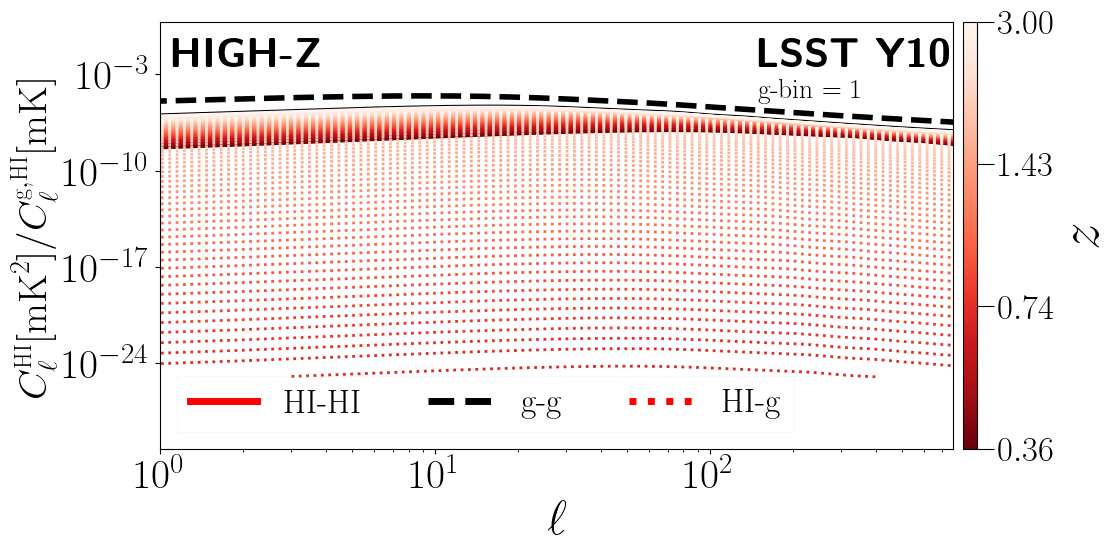

In [5]:
fig, ax  = plt.subplots(nrows=1, ncols=1)
plt.subplots_adjust(top=1.,right=1.6)
############################################################
c    = ibins
norm = mpl.colors.Normalize(vmin=1, vmax=int(nch))
cmap_f1 = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds.reversed())
cmap_f1.set_array([])
cmap_cx = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds_r)#.reversed())
cmap_cx.set_array([])
############################################################
### LSST Y10 bin1
jj=0
ishear = bshear_names[jj]
#
ax.plot(Clcx_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')
ax.plot(Clf1_dict[ishear]['l'], Clf1_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')     
for i,iname in enumerate(np.flip(bin_names)):
    if iname!='l':
        thres = 1e-25
        l  = Clcx_dict[ishear]['l']
        cl = Clcx_dict[ishear][iname]
        idx = np.where(cl>thres)
        ax.plot(l[idx], cl[idx], color=cmap_cx.to_rgba(i + 1), lw=2, ls='dotted')
    if iname!='l':ax.plot(Clf1_dict[ishear]['l'], Clf1_dict[ishear][iname], linestyle='solid', color=cmap_f1.to_rgba(i + 1))   
ax.plot(Clf1_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(nch)],linestyle='solid', linewidth=1, color='black')   
ax.plot(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin{}'.format(1)],linestyle='dashed', linewidth=4, color='black')   
#
ax.set_ylabel(r'$C_{\ell}\ [\textrm{mK}^{\Large\textrm{(m)}}]$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_ylabel(r'$C^{\LARGE{\textrm{HI}}}_{\ell}[\textrm{mK}^2]$' + r'$/$'+ r'$C^{\LARGE{\textrm{g}},\LARGE{\textrm{HI}}}_{\ell}[\textrm{mK}]$', fontsize=29); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_xlim([1, Clf2_dict[ishear]['l'].max()])
ax.set_ylim([0.6e-30, 7e0])
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_yscale('log'); ax.set_xscale('log')
############################################################
cbar=fig.colorbar(cmap_cx, ax=ax, #location='top',
                  orientation='vertical',# extend="both",
                  pad=0.01, aspect=30, ticks=cticks,
                  format=mticker.FixedFormatter(np.array([ r'${:.2f}$'.format(izeff) for izeff in np.flip(zeff) ])) )
cbar.ax.tick_params(axis='both', which='major', labelsize=25, length=12)
cbar.set_label( label=r'$z$', fontsize=40)
###########################################################
custom_lines = [Line2D([], [], color='red',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='black',
                             linewidth=5, linestyle='dashed'),
                Line2D([], [], color='red',
                             linewidth=5, linestyle='dotted')
               ]
ax.legend(custom_lines, [r'$\textrm{HI-HI}$',#\ [\textrm{mK}^2]$',#\ (\textrm{m}=2)$', 
                         r'$\textrm{g-g}$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                         r'$\textrm{HI-g}$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                        ], ncols=3,
         fontsize=24, loc='lower left',framealpha=0.1, fancybox=False)

ax.text(x=1.1    , y=4e-3, s=r'$\textbf{HIGH-Z}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-150, y=4e-3, s=r'$\textbf{LSST Y10}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-150, y=2e-5, s=r'$\textrm{g}\textrm{-bin} = '+'{}$'.format(int(ishear.split('bin')[1])+1), 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 20})
###########################################################
if suffix==None: pathname = "/data/AMARINS/LSSxHI-CODES/images/{}_{}_density.png".format( prefix[jj], 'cl_hi_theory')
else:            pathname = "/data/AMARINS/LSSxHI-CODES/images/{}_{}_density_{}.png".format(prefix[jj], 'cl_hi_theory',suffix)
#if savefigs: plt.savefig(pathname, dpi=100, bbox_inches='tight');
pathname

'/data/AMARINS/LSSxHI-CODES/images/LSSTY10_bin1_cl_hi_theory_density_nch70_350_1050.png'

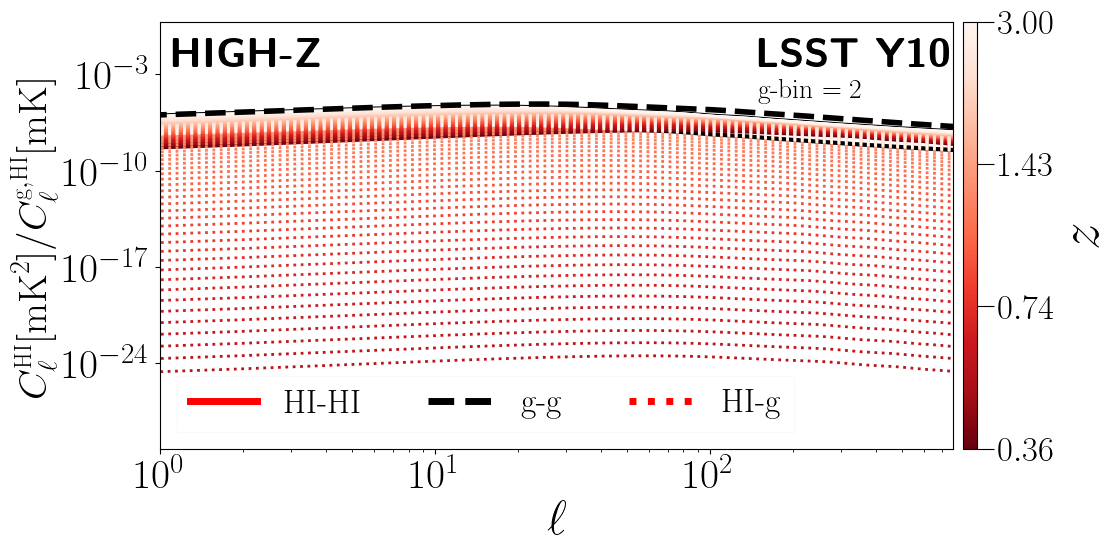

In [6]:
fig, ax  = plt.subplots(nrows=1, ncols=1)
plt.subplots_adjust(top=1.,right=1.6)
############################################################
c    = ibins
norm = mpl.colors.Normalize(vmin=1, vmax=int(nch))
cmap_f1 = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds.reversed())
cmap_f1.set_array([])
cmap_cx = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds_r)#.reversed())
cmap_cx.set_array([])
############################################################
### LSST Y10 bin1
jj=1
ishear = bshear_names[jj]
#
ax.plot(Clcx_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')
ax.plot(Clf1_dict[ishear]['l'], Clf1_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')     
for i,iname in enumerate(np.flip(bin_names)):
    if iname!='l':
        thres = 1e-25
        l  = Clcx_dict[ishear]['l']
        cl = Clcx_dict[ishear][iname]
        idx = np.where(cl>thres)
        ax.plot(l[idx], cl[idx], color=cmap_cx.to_rgba(i + 1), lw=2, ls='dotted')
    if iname!='l':ax.plot(Clf1_dict[ishear]['l'], Clf1_dict[ishear][iname], linestyle='solid', color=cmap_f1.to_rgba(i + 1))   
ax.plot(Clf1_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(nch)],linestyle='solid', linewidth=1, color='black')   
ax.plot(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin{}'.format(1)],linestyle='dashed', linewidth=4, color='black')   
#
ax.set_ylabel(r'$C_{\ell}\ [\textrm{mK}^{\Large\textrm{(m)}}]$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_ylabel(r'$C^{\LARGE{\textrm{HI}}}_{\ell}[\textrm{mK}^2]$' + r'$/$'+ r'$C^{\LARGE{\textrm{g}},\LARGE{\textrm{HI}}}_{\ell}[\textrm{mK}]$', fontsize=29); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_xlim([1, Clf2_dict[ishear]['l'].max()])
ax.set_ylim([0.6e-30, 7e0])
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_yscale('log'); ax.set_xscale('log')
############################################################
cbar=fig.colorbar(cmap_cx, ax=ax, #location='top',
                  orientation='vertical',# extend="both",
                  pad=0.01, aspect=30, ticks=cticks,
                  format=mticker.FixedFormatter(np.array([ r'${:.2f}$'.format(izeff) for izeff in np.flip(zeff) ])) )
cbar.ax.tick_params(axis='both', which='major', labelsize=25, length=12)
cbar.set_label( label=r'$z$', fontsize=40)
###########################################################
custom_lines = [Line2D([], [], color='red',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='black',
                             linewidth=5, linestyle='dashed'),
                Line2D([], [], color='red',
                             linewidth=5, linestyle='dotted')
               ]
ax.legend(custom_lines, [r'$\textrm{HI-HI}$',#\ [\textrm{mK}^2]$',#\ (\textrm{m}=2)$', 
                         r'$\textrm{g-g}$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                         r'$\textrm{HI-g}$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                        ], ncols=3,
         fontsize=24, loc='lower left',framealpha=0.1, fancybox=False)

ax.text(x=1.1    , y=4e-3, s=r'$\textbf{HIGH-Z}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-150, y=4e-3, s=r'$\textbf{LSST Y10}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-150, y=2e-5, s=r'$\textrm{g}\textrm{-bin} = '+'{}$'.format(int(ishear.split('bin')[1])+1), 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 20})
###########################################################
if suffix==None: pathname = "/data/AMARINS/LSSxHI-CODES/images/{}_{}_density.png".format( prefix[jj], 'cl_hi_theory')
else:            pathname = "/data/AMARINS/LSSxHI-CODES/images/{}_{}_density_{}.png".format(prefix[jj], 'cl_hi_theory',suffix)
if savefigs: plt.savefig(pathname, dpi=100, bbox_inches='tight');
pathname

'/data/AMARINS/LSSxHI-CODES/images/LSSTY10_bin2_cl_hi_theory_density_nch70_350_1050.png'

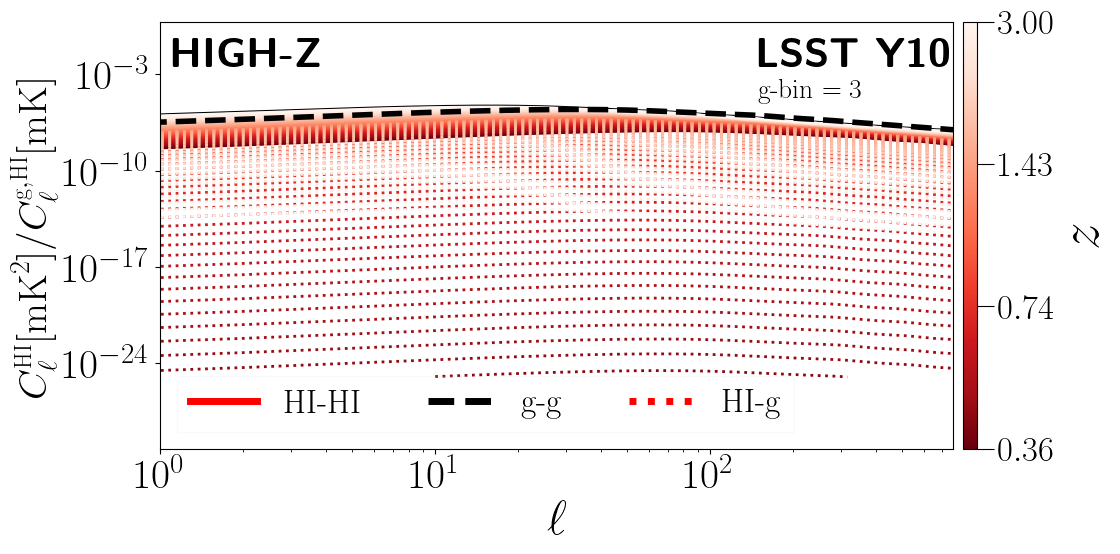

In [7]:
fig, ax  = plt.subplots(nrows=1, ncols=1)
plt.subplots_adjust(top=1.,right=1.6)
############################################################
c    = ibins
norm = mpl.colors.Normalize(vmin=1, vmax=int(nch))
cmap_f1 = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds.reversed())
cmap_f1.set_array([])
cmap_cx = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds_r)#.reversed())
cmap_cx.set_array([])
############################################################
### LSST Y10 bin1
jj=2
ishear = bshear_names[jj]
#
#ax.plot(Clcx_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')
ax.plot(Clf1_dict[ishear]['l'], Clf1_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')     
for i,iname in enumerate(np.flip(bin_names)):
    if iname!='l':
        thres = 1e-25
        l  = Clcx_dict[ishear]['l']
        cl = Clcx_dict[ishear][iname]
        idx = np.where(cl>thres)
        ax.plot(l[idx], cl[idx], color=cmap_cx.to_rgba(i + 1), lw=2, ls='dotted')
    if iname!='l':ax.plot(Clf1_dict[ishear]['l'], Clf1_dict[ishear][iname], linestyle='solid', color=cmap_f1.to_rgba(i + 1))   
ax.plot(Clf1_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(nch)],linestyle='solid', linewidth=1, color='black')   
ax.plot(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin{}'.format(1)],linestyle='dashed', linewidth=4, color='black')   
#
ax.set_ylabel(r'$C_{\ell}\ [\textrm{mK}^{\Large\textrm{(m)}}]$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_ylabel(r'$C^{\LARGE{\textrm{HI}}}_{\ell}[\textrm{mK}^2]$' + r'$/$'+ r'$C^{\LARGE{\textrm{g}},\LARGE{\textrm{HI}}}_{\ell}[\textrm{mK}]$', fontsize=29); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_xlim([1, Clf2_dict[ishear]['l'].max()])
ax.set_ylim([0.6e-30, 7e0])
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_yscale('log'); ax.set_xscale('log')
############################################################
cbar=fig.colorbar(cmap_cx, ax=ax, #location='top',
                  orientation='vertical',# extend="both",
                  pad=0.01, aspect=30, ticks=cticks,
                  format=mticker.FixedFormatter(np.array([ r'${:.2f}$'.format(izeff) for izeff in np.flip(zeff) ])) )
cbar.ax.tick_params(axis='both', which='major', labelsize=25, length=12)
cbar.set_label( label=r'$z$', fontsize=40)
###########################################################
custom_lines = [Line2D([], [], color='red',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='black',
                             linewidth=5, linestyle='dashed'),
                Line2D([], [], color='red',
                             linewidth=5, linestyle='dotted')
               ]
ax.legend(custom_lines, [r'$\textrm{HI-HI}$',#\ [\textrm{mK}^2]$',#\ (\textrm{m}=2)$', 
                         r'$\textrm{g-g}$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                         r'$\textrm{HI-g}$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                        ], ncols=3,
         fontsize=24, loc='lower left',framealpha=0.1, fancybox=False)

ax.text(x=1.1    , y=4e-3, s=r'$\textbf{HIGH-Z}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-150, y=4e-3, s=r'$\textbf{LSST Y10}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-150, y=2e-5, s=r'$\textrm{g}\textrm{-bin} = '+'{}$'.format(int(ishear.split('bin')[1])+1), 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 20})
###########################################################
if suffix==None: pathname = "/data/AMARINS/LSSxHI-CODES/images/{}_{}_density.png".format( prefix[jj], 'cl_hi_theory')
else:            pathname = "/data/AMARINS/LSSxHI-CODES/images/{}_{}_density_{}.png".format(prefix[jj], 'cl_hi_theory',suffix)
if savefigs: plt.savefig(pathname, dpi=100, bbox_inches='tight');
pathname

'/data/AMARINS/LSSxHI-CODES/images/LSSTY10_bin3_cl_hi_theory_density_nch70_350_1050.png'

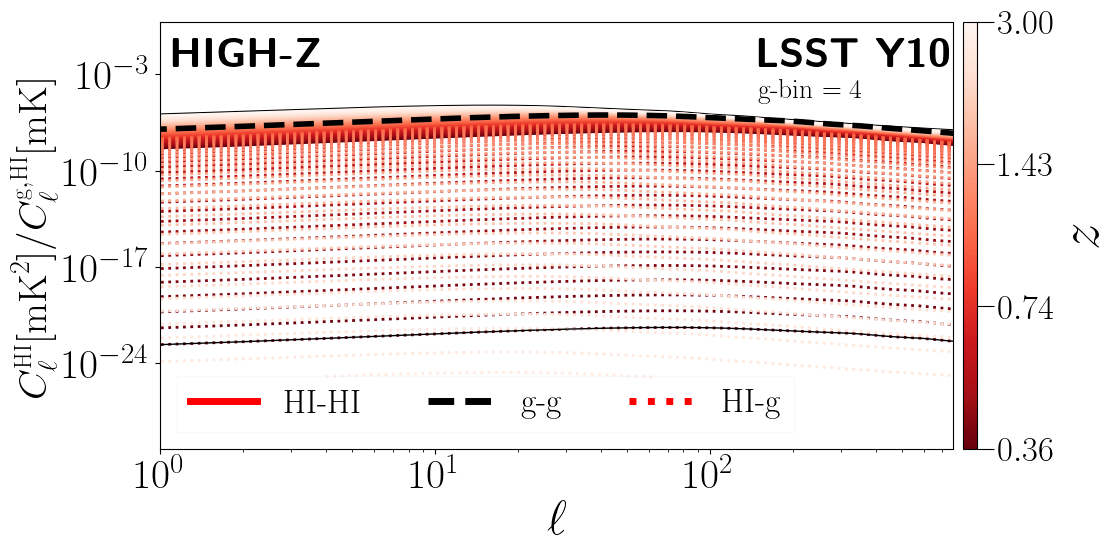

In [74]:
fig, ax  = plt.subplots(nrows=1, ncols=1)
plt.subplots_adjust(top=1.,right=1.6)
############################################################
c    = ibins
norm = mpl.colors.Normalize(vmin=1, vmax=int(nch))
cmap_f1 = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds.reversed())
cmap_f1.set_array([])
cmap_cx = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds_r)#.reversed())
cmap_cx.set_array([])
############################################################
### LSST Y10 bin1
jj=3
ishear = bshear_names[jj]
#
#ax.plot(Clcx_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')
ax.plot(Clf1_dict[ishear]['l'], Clf1_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')     
for i,iname in enumerate(np.flip(bin_names)):
    if iname!='l':
        thres = 1e-25
        l  = Clcx_dict[ishear]['l']
        cl = Clcx_dict[ishear][iname]
        idx = np.where(cl>thres)
        ax.plot(l[idx], cl[idx], color=cmap_cx.to_rgba(i + 1), lw=2, ls='dotted')
    if iname!='l':ax.plot(Clf1_dict[ishear]['l'], Clf1_dict[ishear][iname], linestyle='solid', color=cmap_f1.to_rgba(i + 1))   
ax.plot(Clf1_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(nch)],linestyle='solid', linewidth=1, color='black')   
ax.plot(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin{}'.format(1)],linestyle='dashed', linewidth=4, color='black')   
#
ax.set_ylabel(r'$C_{\ell}\ [\textrm{mK}^{\Large\textrm{(m)}}]$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_ylabel(r'$C^{\LARGE{\textrm{HI}}}_{\ell}[\textrm{mK}^2]$' + r'$/$'+ r'$C^{\LARGE{\textrm{g}},\LARGE{\textrm{HI}}}_{\ell}[\textrm{mK}]$', fontsize=29); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_xlim([1, Clf2_dict[ishear]['l'].max()])
ax.set_ylim([0.6e-30, 7e0])
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_yscale('log'); ax.set_xscale('log')
############################################################
cbar=fig.colorbar(cmap_cx, ax=ax, #location='top',
                  orientation='vertical',# extend="both",
                  pad=0.01, aspect=30, ticks=cticks,
                  format=mticker.FixedFormatter(np.array([ r'${:.2f}$'.format(izeff) for izeff in np.flip(zeff) ])) )
cbar.ax.tick_params(axis='both', which='major', labelsize=25, length=12)
cbar.set_label( label=r'$z$', fontsize=40)
###########################################################
custom_lines = [Line2D([], [], color='red',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='black',
                             linewidth=5, linestyle='dashed'),
                Line2D([], [], color='red',
                             linewidth=5, linestyle='dotted')
               ]
ax.legend(custom_lines, [r'$\textrm{HI-HI}$',#\ [\textrm{mK}^2]$',#\ (\textrm{m}=2)$', 
                         r'$\textrm{g-g}$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                         r'$\textrm{HI-g}$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                        ], ncols=3,
         fontsize=24, loc='lower left',framealpha=0.1, fancybox=False)

ax.text(x=1.1    , y=4e-3, s=r'$\textbf{HIGH-Z}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-150, y=4e-3, s=r'$\textbf{LSST Y10}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-150, y=2e-5, s=r'$\textrm{g}\textrm{-bin} = '+'{}$'.format(int(ishear.split('bin')[1])+1), 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 20})
###########################################################
if suffix==None: pathname = "/data/AMARINS/LSSxHI-CODES/images/{}_{}_density.png".format( prefix[jj], 'cl_hi_theory')
else:            pathname = "/data/AMARINS/LSSxHI-CODES/images/{}_{}_density_{}.png".format(prefix[jj], 'cl_hi_theory',suffix)
if savefigs: plt.savefig(pathname, dpi=100, bbox_inches='tight');
pathname

'/data/AMARINS/LSSxHI-CODES/images/LSSTY10_bin4_cl_hi_theory_density_nch70_350_1050.png'

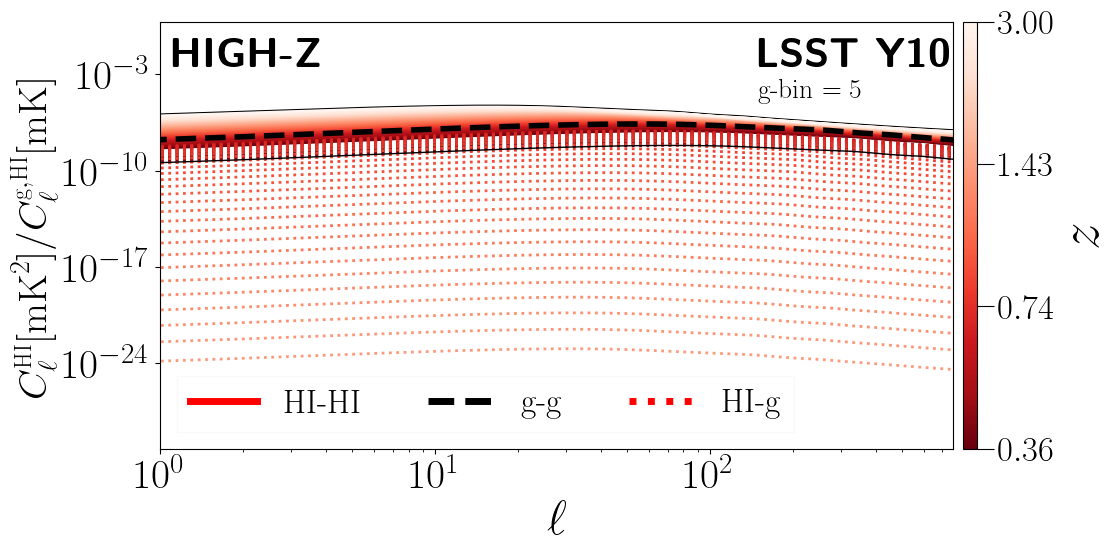

In [73]:
fig, ax  = plt.subplots(nrows=1, ncols=1)
plt.subplots_adjust(top=1.,right=1.6)
############################################################
c    = ibins
norm = mpl.colors.Normalize(vmin=1, vmax=int(nch))
cmap_f1 = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds.reversed())
cmap_f1.set_array([])
cmap_cx = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.Reds_r)#.reversed())
cmap_cx.set_array([])
############################################################
### LSST Y10 bin1
jj=4
ishear = bshear_names[jj]
#
#ax.plot(Clcx_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')
ax.plot(Clf1_dict[ishear]['l'], Clf1_dict[ishear]['bin{}'.format(1)],linestyle='solid', linewidth=3, color='black')     
for i,iname in enumerate(np.flip(bin_names)):
    if iname!='l':
        thres = 1e-25
        l  = Clcx_dict[ishear]['l']
        cl = Clcx_dict[ishear][iname]
        idx = np.where(cl>thres)
        ax.plot(l[idx], cl[idx], color=cmap_cx.to_rgba(i + 1), lw=2, ls='dotted')
    if iname!='l':ax.plot(Clf1_dict[ishear]['l'], Clf1_dict[ishear][iname], linestyle='solid', color=cmap_f1.to_rgba(i + 1))   
ax.plot(Clf1_dict[ishear]['l'], Clcx_dict[ishear]['bin{}'.format(nch)],linestyle='solid', linewidth=1, color='black')   
ax.plot(Clf2_dict[ishear]['l'], Clf2_dict[ishear]['bin{}'.format(1)],linestyle='dashed', linewidth=4, color='black')   
#
ax.set_ylabel(r'$C_{\ell}\ [\textrm{mK}^{\Large\textrm{(m)}}]$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_ylabel(r'$C^{\LARGE{\textrm{HI}}}_{\ell}[\textrm{mK}^2]$' + r'$/$'+ r'$C^{\LARGE{\textrm{g}},\LARGE{\textrm{HI}}}_{\ell}[\textrm{mK}]$', fontsize=29); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.set_xlim([1, Clf2_dict[ishear]['l'].max()])
ax.set_ylim([0.6e-30, 7e0])
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_yscale('log'); ax.set_xscale('log')
############################################################
cbar=fig.colorbar(cmap_cx, ax=ax, #location='top',
                  orientation='vertical',# extend="both",
                  pad=0.01, aspect=30, ticks=cticks,
                  format=mticker.FixedFormatter(np.array([ r'${:.2f}$'.format(izeff) for izeff in np.flip(zeff) ])) )
cbar.ax.tick_params(axis='both', which='major', labelsize=25, length=12)
cbar.set_label( label=r'$z$', fontsize=40)
###########################################################
custom_lines = [Line2D([], [], color='red',
                             linewidth=5, linestyle='solid'),
                Line2D([], [], color='black',
                             linewidth=5, linestyle='dashed'),
                Line2D([], [], color='red',
                             linewidth=5, linestyle='dotted')
               ]
ax.legend(custom_lines, [r'$\textrm{HI-HI}$',#\ [\textrm{mK}^2]$',#\ (\textrm{m}=2)$', 
                         r'$\textrm{g-g}$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                         r'$\textrm{HI-g}$',#\ [\textrm{mK}^1]$',#\ (\textrm{m}=1)$', 
                        ], ncols=3,
         fontsize=24, loc='lower left',framealpha=0.1, fancybox=False)

ax.text(x=1.1    , y=4e-3, s=r'$\textbf{HIGH-Z}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-150, y=4e-3, s=r'$\textbf{LSST Y10}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
ax.text(x=300-150, y=2e-5, s=r'$\textrm{g}\textrm{-bin} = '+'{}$'.format(int(ishear.split('bin')[1])+1), 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 20})
###########################################################
if suffix==None: pathname = "/data/AMARINS/LSSxHI-CODES/images/{}_{}_density.png".format( prefix[jj], 'cl_hi_theory')
else:            pathname = "/data/AMARINS/LSSxHI-CODES/images/{}_{}_density_{}.png".format(prefix[jj], 'cl_hi_theory',suffix)
if savefigs: plt.savefig(pathname, dpi=100, bbox_inches='tight');
pathname

# ALL

In [78]:
CLf1,CLf2,CLcx = {}, {}, {}
for i,(iname,isuffix) in enumerate(zip(['LOW-Z','HIGH-Z'],['nch30_980_1260', 'nch70_350_1050'])):
    f1name = 'HI'
    f2name = 'DENSITY'
    #suffix = 'nch30_980_1260'
    prefix = np.array(['LSSTY10_bin{}'.format(i)  for i       in range(5)])
    b_names= np.array([     iprefix.split('_')[1] for iprefix in prefix  ])
    b_used = np.array([ int(ibin.split('bin')[1]) for ibin    in b_names ])

    filepath_f1 = np.array(['/data/AMARINS/LSSxHI-DATA/theoretical/GCxHI/{ip}_{f1}_cl_{sf}.txt'.format(ip=iprefix, 
                                                                                                       sf=isuffix, 
                                                                                                       f1=f1name) for iprefix in prefix])
    filepath_f2 = np.array(['/data/AMARINS/LSSxHI-DATA/theoretical/GCxHI/{ip}_{f2}_cl_{sf}.txt'.format(ip=iprefix, 
                                                                                                       sf=isuffix, 
                                                                                                       f2=f2name) for iprefix in prefix])
    filepath_cx = np.array(['/data/AMARINS/LSSxHI-DATA/theoretical/GCxHI/{ip}_{f1}x{f2}_cl_{sf}.txt'.format(ip=iprefix, 
                                                                                                            sf=isuffix, 
                                                                                                            f1=f1name, 
                                                                                                            f2=f2name) for iprefix in prefix])

    Clf1_dict,Clf2_dict,Clcx_dict = {}, {}, {}
    for i, (ibin, if1_path, if2_path, icx_path) in enumerate(zip(b_names, filepath_f1, filepath_f2, filepath_cx)):
        ##
        clf1 = np.loadtxt(if1_path).T
        clf2 = np.loadtxt(if2_path).T
        clcx = np.loadtxt(icx_path ).T
        ##
        Clf1_dict[ibin] = cxft.cls_from_matrix2dict(clf1)
        Clf2_dict[ibin] = cxft.cls_from_matrix2dict(clf2)
        Clcx_dict[ibin] = cxft.cls_from_matrix2dict(clcx)
        ##
        nch = int(clf1.shape[0])-1
        del clf1, clf2, clcx
    CLf1[iname]=dcopy(Clf1_dict)
    CLf2[iname]=dcopy(Clf2_dict)
    CLcx[iname]=dcopy(Clcx_dict)
    del Clf1_dict,Clf2_dict,Clcx_dict

In [79]:
ngbins, nhbins, nl =  len(CLf1['LOW-Z'].keys()), len(CLf1['LOW-Z']['bin1'].keys())-1, CLf1['LOW-Z']['bin1']['bin1'].size
ngbins, nhbins, nl

(5, 30, 768)

''

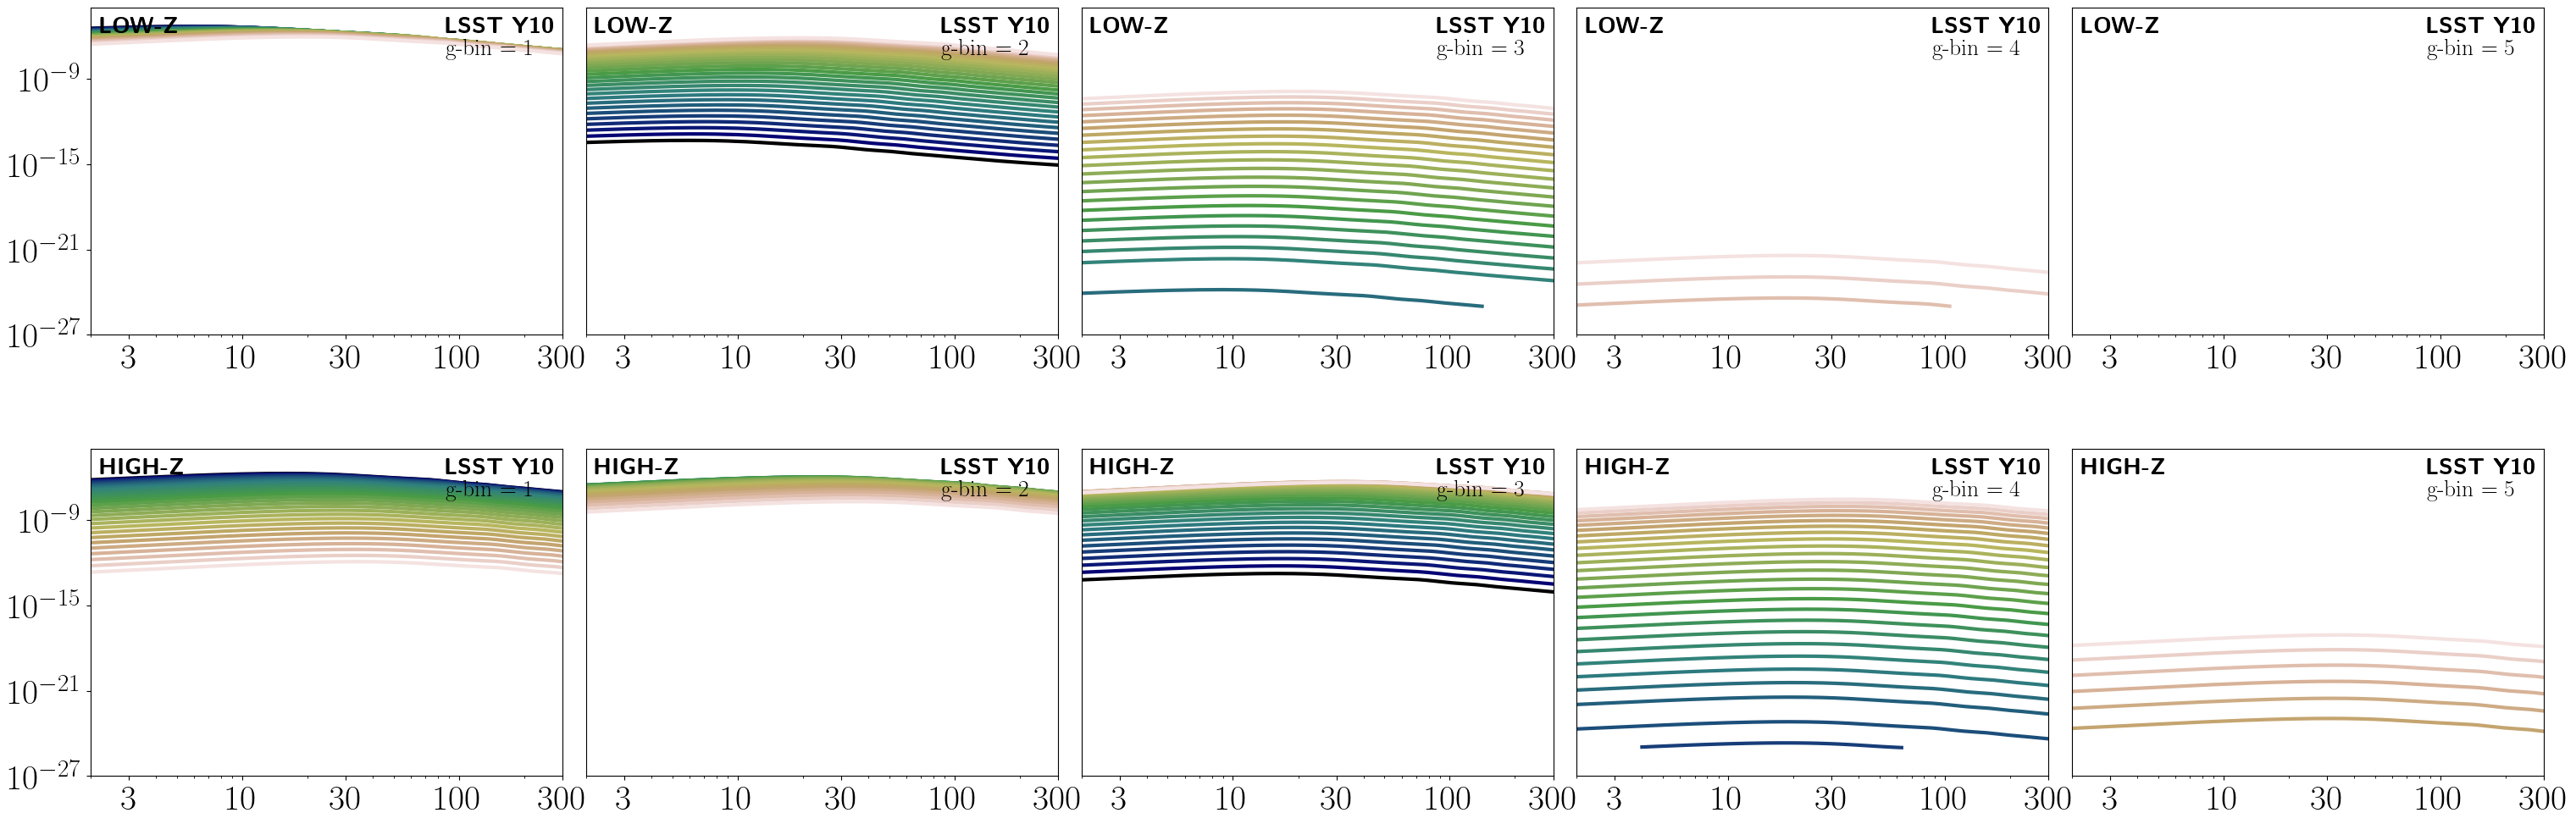

In [80]:
ncols,nrows = 5,2
fig, axes   = plt.subplots(nrows=nrows, ncols=ncols)
plt.subplots_adjust(top=1*nrows,right=(0.93)*ncols, wspace=0.05, hspace=0.35)
############################################################
thres=1e-35
iname='LOW-Z'
ngbins, nhbins, nl =  len(CLf1[iname].keys()), len(CLf1[iname]['bin1'].keys())-1, CLf1[iname]['bin1']['bin1'].size
############################################################
N    = nhbins
c    = np.arange(1., nhbins + 1)
norm = mpl.colors.BoundaryNorm(np.arange(1, N+2,1),N)
cmap = plt.get_cmap("gist_earth", N+1)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
############################################################
iname='LOW-Z'
for i in range(ngbins):
    ax = axes[0, i]
    ibin='bin{}'.format(i)
    for j in range(nhbins): 
        jbin = 'bin{}'.format(j+1)
        l  = CLcx[iname][ibin]['l']
        cl = CLcx[iname][ibin][jbin]
        idx = np.where(cl>thres)
        ax.plot(l[idx], cl[idx], c=cmap(j), lw=3, ls='solid')
    ax.set_yscale('log'); ax.set_xscale('log')    
    #ax.set_xlabel(r"$\ell$"   , fontsize =30)
    #ax.set_ylabel(r"$n^{(i)}$", fontsize =30)    
    ax.tick_params(axis='both', which='major' , labelsize=30)
    ax.set_xlim(2,300)
    cxticks = [3,10,30,100,300]
    ax.set_xticks(cxticks, [r'${}$'.format(s) for s in cxticks])
    ax.set_ylim(1e-27,1e-4)
    if i: ax.set_yticks([])
    ax.text(x=2.2, y=2e-6, s=r'$\textbf{LOW-Z}$', 
            fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 20})    
    ax.text(x=87, y=2e-6, s=r'$\textbf{LSST Y10}$', 
            fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 20})
    ax.text(x=87, y=0.5e-7, s=r'$\textrm{g}\textrm{-bin} = '+'{}$'.format(i+1), 
            fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 20}) 
############################################################
############################################################
iname='HIGH-Z'
for i in range(ngbins):
    ax = axes[1, i]
    ibin='bin{}'.format(i)
    for j in range(nhbins): 
        jbin = 'bin{}'.format(j+1)
        l  = CLcx[iname][ibin]['l']
        cl = CLcx[iname][ibin][jbin]
        idx = np.where(cl>thres)
        ax.plot(l[idx], cl[idx], c=cmap(j), lw=3, ls='solid')
    ax.set_yscale('log'); ax.set_xscale('log')    
    #ax.set_xlabel(r"$\ell$"   , fontsize =30)
    #ax.set_ylabel(r"$n^{(i)}$", fontsize =30)    
    ax.tick_params(axis='both', which='major' , labelsize=30)
    ax.set_xlim(2,300)
    cxticks = [3,10,30,100,300]
    ax.set_xticks(cxticks, [r'${}$'.format(s) for s in cxticks])
    ax.set_ylim(1e-27,1e-4)
    if i: ax.set_yticks([])
    ax.text(x=2.2, y=2e-6, s=r'$\textbf{HIGH-Z}$', 
            fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 20})    
    ax.text(x=87, y=2e-6, s=r'$\textbf{LSST Y10}$', 
            fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 20})
    ax.text(x=87, y=0.5e-7, s=r'$\textrm{g}\textrm{-bin} = '+'{}$'.format(i+1), 
            fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 20})     
############################################################
#ax1.text(x=-0.05, y=6, s=r'$\textbf{LSST}$', 
#        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 20})
;

In [19]:
iname='LOW-Z'
CLg = {'LOW-Z' : np.vstack([ CLf2['LOW-Z']['bin{}'.format(i)]['bin1'] for i in range(5)]) ,
       'HIGH-Z': np.vstack([ CLf2['HIGH-Z']['bin{}'.format(i)]['bin1'] for i in range(5)]) 
      }

In [21]:
import camb
params = { 'H0'   : 67.5,
           'ombh2': 0.022,
           'omch2': 0.122,
           'ns'   : 0.965,
           'z'    : np.logspace(np.log10(1e-10),np.log10(1150), 150),
           'kmax' : 100,
           'minkh': 1e-4,
           'maxkh': 100,
           'npoints': 1e8,
           'nonlinear':True,
           'halofit_version':'mead2020'}       


#pars = camb.CAMBparams()
cpars = camb.set_params(halofit_version=params['halofit_version'])#, HMCode_A_baryon=3.13, HMCode_eta_baryon=0.603, HMCode_logT_AGN=7.8)
                       #H0=params['H0'], ombh2=params['ombh2'], omch2=params['omch2'])
cpars.set_cosmology(H0=params['H0'], ombh2=params['ombh2'], omch2=params['omch2'])
cpars.InitPower.set_params(ns=params['ns'])
cpars.set_matter_power(redshifts=params['z'], kmax=params['kmax'])
#pars.NonLinear = model.NonLinear_both
#results.calc_power_spectra(pars)
cresults  = camb.get_results(cpars)
pk_interp = camb.get_matter_power_interpolator(cpars, 
                                               nonlinear=params['nonlinear'], hubble_units=False, k_hunit=False, 
                                               kmax=params['kmax'], zmax=params['z'][-1])
cresults.z_input = params['z']
print("done.")

Note: redshifts have been re-sorted (earliest first)
done.


'/data/AMARINS/LSSxHI-CODES/images/LSSTY10_shear_nch70_350_1050.png'

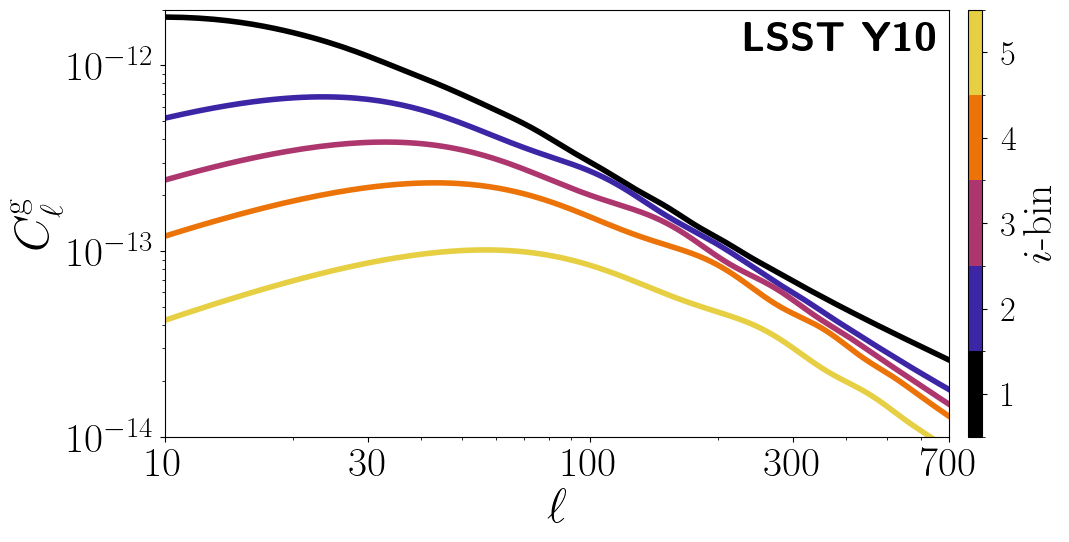

In [20]:
fig, ax  = plt.subplots(nrows=1, ncols=1)
plt.subplots_adjust(top=1.,right=1.6)
############################################################
nch,N  = 5, 5
c    = np.arange(1., nch + 1)
norm = mpl.colors.BoundaryNorm(np.arange(1, N+2,1),N)
cmap2 = plt.get_cmap("CMRmap", N+1)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap2)
sm.set_array([])
############################################################
thres = 1e-100
iname = 'LOW-Z'
l = np.arange(CLg[iname].shape[1])
for i in range(CLg[iname].shape[0]):
    cl = dcopy(CLg[iname][i,:])
    ind = np.where( (cl<thres)*(cl>-thres) )
    ax.plot(l, cl, linestyle='solid', color=cmap2(i), lw=4)
    
ax.set_ylabel(r'$C^{\Huge \textrm{g}}_{\ell}$', fontsize=35); ax.set_xlabel(r'$\ell$', fontsize=35)
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_yscale('log'); ax.set_xscale('log')
ax.set_xlim([10, 700])
cxticks = [10,30,100,300,700]
ax.set_xticks(cxticks, [r'${}$'.format(s) for s in cxticks])
ax.set_ylim([1e-14, 2e-12])
###########################################################
ax.text(x=230, y=1.2e-12, s=r'$\textbf{LSST Y10}$', 
        fontdict={'family': 'serif', 'color':  None,  'weight': 'bold','size': 30})
###########################################################
cticks = np.arange(1, N+1,1)#np.linspace(1, len(c)+1, len(c), dtype=np.int8)
cbar=fig.colorbar(sm, ax=ax,pad=0.02, aspect=30, ticks=cticks+0.5)
cbar.set_label(label=r'$i\textrm{-bin}$',size=30)#,weight='bold')
cticks = np.array([r'${}$'.format(i) for i in cticks])
cbar.ax.set_yticklabels(cticks)
cbar.ax.tick_params(labelsize=25, pad=10)
###########################################################
if suffix==None: pathname = "/data/AMARINS/LSSxHI-CODES/images/{}_{}.png".format('LSSTY10', 'shear')
else:            pathname = "/data/AMARINS/LSSxHI-CODES/images/{}_{}_{}.png".format('LSSTY10', 'shear',suffix)
#if savefigs: plt.savefig(pathname, dpi=100, bbox_inches='tight');
pathname